# The same company, two prices — and nobody can fix it 🇨🇳
### The A-H share premium, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cheap H the better buy?: Busted](https://img.shields.io/badge/Cheap_H_the_better_buy%3F-Busted-8b949e?style=flat-square)

Ping An, PetroChina, ICBC — many of China's biggest companies are listed **twice**: once in **Shanghai** (an *A-share*, priced in yuan) and once in **Hong Kong** (an *H-share*, priced in HK dollars). Same company, same profits, same dividend, share for share. The folklore says the Shanghai ticket costs about **30% more** — and that nobody can arbitrage it away, because you can't convert one share into the other and you can't short-sell the expensive one.

Most market legends shrink when you measure them. This one **doesn't**: our 14-pair average over 16.5 years is **+29.7%** — the folklore number *is* the tape's number.

> 📓 **Plain-language layer.** Want the *t*-stats, the unit-root tests and the Monte-Carlo placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Our panel is 14 pairs *still dual-listed today* — mega-cap state firms, the corner where the premium is best documented. That carries **survivorship**, and we say so. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from a_h_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CLOSE, ADJ = data.load_real()
    PREM_M = st.monthly_premium(st.premium_panel(CLOSE))
    REL_M = st.monthly_rel_returns(ADJ)
    EW = PREM_M.mean(axis=1).dropna()
else:
    CLOSE = ADJ = PREM_M = REL_M = EW = None
print("real A-H cache present:", HAVE_REAL,
      "| months:", (0 if EW is None else len(EW)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-01', 'end': '2026-06-30', 'years': 16.5, 'n_pairs': 14, 'n_months': 198, 'mean_pct': 29.69, 'hac12_t': 5.12, 'hac36_t': 3.29, 'share_pos': 84.8, 'last_neg': '2014-10', 'asof_pct': 33.1, 'min_pct': -11.7, 'max_pct': 77.1, 'post_mean': 41.9, 'post_t': 9.19, 'post_n': 139, 'n_pairs_pos': 13, 'widest': ('Great Wall Motor', 83.6), 'second': ('China Life', 74.5), 'narrowest': ('Ping An Insurance', -0.5), 'mc': [('calibrated AR(1) (phi 0.977, innov sd 0.0501)', 0.0177, 0.089), ('stress phi = 0.995', 0.2372, 0.2712), ('random walk from the 2010 start', 0.4405, 0.5118)], 'phi': 0.977, 'se_phi': 0.015, 'half_life': 30.4, 'df_t': -1.49, 'df_crit': -2.86, 'hl_median': 11.3, 'hl_min': 5.5, 'hl_max': 45.1, 'pair_corr': 0.322, 'pc1': 39.2, 'indep': 7.1, 'cm_months': 176, 'fade': [('gross, headline', 61.9, 5.09), ('skip-a-month', 45.5, 4.84), ('2010-01 - 2018-06', 84.9, 5.17), ('2018-07 - 2026-06', 36.4, 2.36), ('ex 2 extremes (GWM, China Life)', 60.5, 6.32), ('price-only (no dividends)', 64.1, 5.38), ('random halves (20-seed baseline)', -2.6, -0.26), ('z-portfolio', 63.5, 5.04), ('own-history time-series fade', 43.0, 1.39), ('unconditional carry (long H / short A)', 6.8, 0.26)], 'fade_ann': 7.68, 'fade_churn': 11.4, 'feas': [('gross', 54.7, 2.09), ('net 25 bps + 1.5%/yr borrow', 30.9, 1.19), ('net 50 bps + 3.0%/yr borrow', 7.1, 0.27), ('gross 2010-01 - 2018-06', 82.7, 1.91), ('gross 2018-07 - 2026-06', 24.9, 0.95)], 'feas_net_ann': 3.77, 'h_ann': 9.36, 'a_ann': 8.13, 'h_wealth': 4.35, 'a_wealth': 3.61, 'race_bps': 11.6, 'race_t': 0.42, 'race_years': 16.4, 'syn_level': [(30.0, 29.79, 0, 40), (0.0, -0.21, 0, 26)], 'syn_fade': [(0.97, 5.01), (1.0, 0.44)], 'fingerprint': 'f54aaa8986a9'}


real A-H cache present: True | months: 198


## The answer first

| Question | Answer |
|---|---|
| Does Shanghai really pay ~30% more? | **Yes.** 14-pair average **+29.7%** over 2010–2026; positive **139 months in a row** since late 2014; as of June 2026 it sits at **+33%**. |
| Does the gap ever close? | **No.** Statistically you cannot tell the premium from a random walk — there is no force pulling the two prices together. |
| Can you trade it? | **Not really.** The one trade that works on paper needs to short-sell Shanghai shares — which is exactly what nobody is allowed to do. |
| Is the cheap Hong Kong line at least the better buy? | **Couldn't prove it.** 16 years of a 30% discount earned about +1.2 pp/yr — statistically indistinguishable from zero. |

## 1 · One company, two tickets

An A-share and an H-share of Ping An are the **same claim on the same company** — identical par value, identical dividend per share, identical vote. The only difference is the exchange, the currency, and **who is allowed to hold it**. Mainland savers mostly can't take money abroad; foreigners were long locked out of Shanghai. Two pools of money, two moods, one company — two prices.

We convert every Hong Kong price into yuan at the day's exchange rate and ask: **how much more does Shanghai pay for the identical share?**

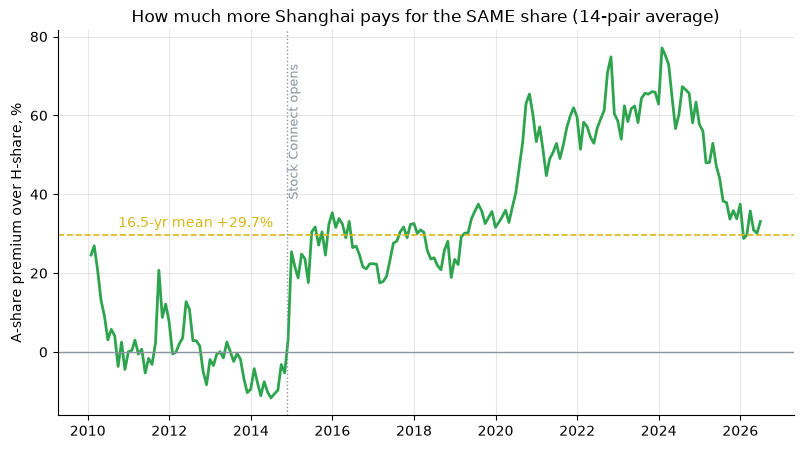

mean +29.69%  |  positive in 84.8% of months  |  last negative month 2014-10


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    ax.plot(EW.index, EW.values * 100, color=GREEN, lw=2)
    ax.axhline(0, color=GREY, lw=1)
    ax.axhline(R['mean_pct'], color=AMBER, lw=1.2, ls='--')
    ax.annotate(f"16.5-yr mean {R['mean_pct']:+.1f}%", xy=(EW.index[8], R['mean_pct'] + 2),
                color=AMBER, fontsize=10)
    connect = pd.Timestamp('2014-11-17')
    ax.axvline(connect, color=GREY, lw=1, ls=':')
    ax.annotate('Stock Connect opens', xy=(connect, EW.values.max() * 100 - 4),
                color=GREY, fontsize=9, rotation=90, va='top')
    ax.set_title('How much more Shanghai pays for the SAME share (14-pair average)')
    ax.set_ylabel('A-share premium over H-share, %')
    plt.show()
    print(f"mean {R['mean_pct']:+.2f}%  |  positive in {R['share_pos']:.1f}% of months"
          f"  |  last negative month {R['last_neg']}")
else:
    print('cache missing — headline:', R['mean_pct'], '% mean premium')

The one moment the premium *almost* died — 2014 — is the moment **Stock Connect** opened, the pipe that lets mainlanders buy Hong Kong stocks and foreigners buy Shanghai. The textbook said the gap should close. Instead, mainland money poured into *both* sides, and since December 2014 the premium has been positive **every single month** (139 in a row), averaging **+41.9%**. The pipe lets you *buy* both tickets — it still doesn't let anyone *swap* them.

## 2 · It's not one weird stock — it's all of them

Thirteen of our fourteen pairs cost more in Shanghai on average. And their premiums breathe **together** — one market-wide gap, not fourteen coincidences.

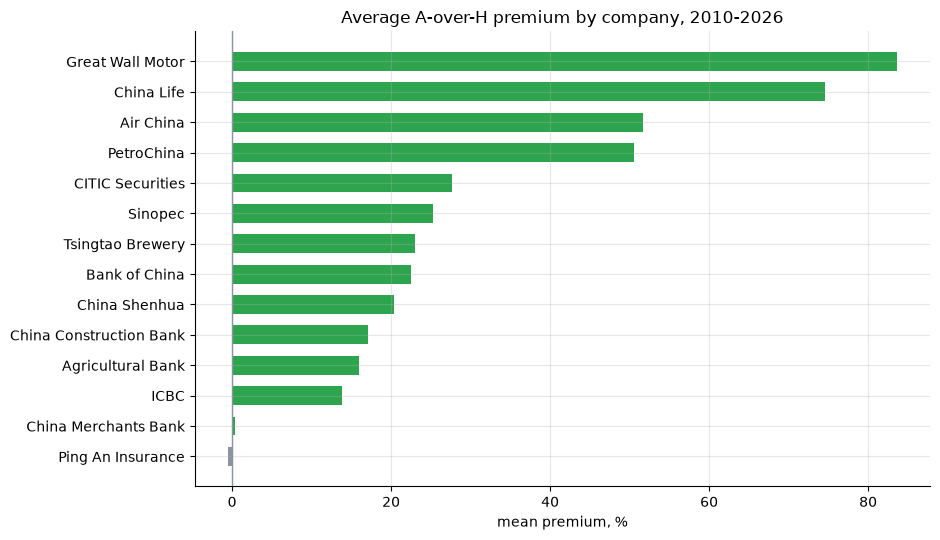

13/14 pairs positive; widest Great Wall Motor +83.6%, narrowest Ping An Insurance -0.5%


In [3]:
if HAVE_REAL:
    pp = PREM_M.mean().sort_values() * 100
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    colors = [GREEN if v > 0 else GREY for v in pp.values]
    ax.barh(pp.index, pp.values, color=colors, height=0.62)
    ax.axvline(0, color=GREY, lw=1)
    ax.set_title('Average A-over-H premium by company, 2010-2026')
    ax.set_xlabel('mean premium, %')
    plt.tight_layout(); plt.show()
    print(f"{R['n_pairs_pos']}/{R['n_pairs']} pairs positive; widest "
          f"{R['widest'][0]} {R['widest'][1]:+.1f}%, narrowest {R['narrowest'][0]} "
          f"{R['narrowest'][1]:+.1f}%")

## 3 · Why can't anyone fix it?

Every arbitrage needs a **channel**. Here, every door is locked:

1. **You can't convert.** An H-share never becomes an A-share. There is no redemption machine like an ETF's.
2. **You can't short the expensive side.** Selling borrowed A-shares is the trade — but Stock Connect has no stock-lending, and China suspended the domestic relending channel in 2024. The people who can see the spread cannot short Shanghai.
3. **Money can't move freely.** Capital controls keep mainland savings mostly at home, chasing a limited menu of domestic assets.

So the gap isn't an oversight — it's the *price of segmentation*, quoted daily. The statisticians' version: the premium is indistinguishable from a **random walk** (no pull toward zero at all).

> 🔬 **For the quants.** The level has AR(1) φ = 0.977 and a Dickey-Fuller *t* of −1.49 vs −2.86 — a unit root you cannot reject. The full inference (and why we refuse to certify a level with an HAC *t* alone) is in notebook 02.

## 4 · "So buy the cheap one" — we checked

If the same dividends cost 30% less in Hong Kong, the H-share pays a ~30% higher dividend yield forever. Surely the cheap line wins in the long run? Here is the race: one yuan in the H basket vs one yuan in the A basket, dividends reinvested, both counted in yuan.

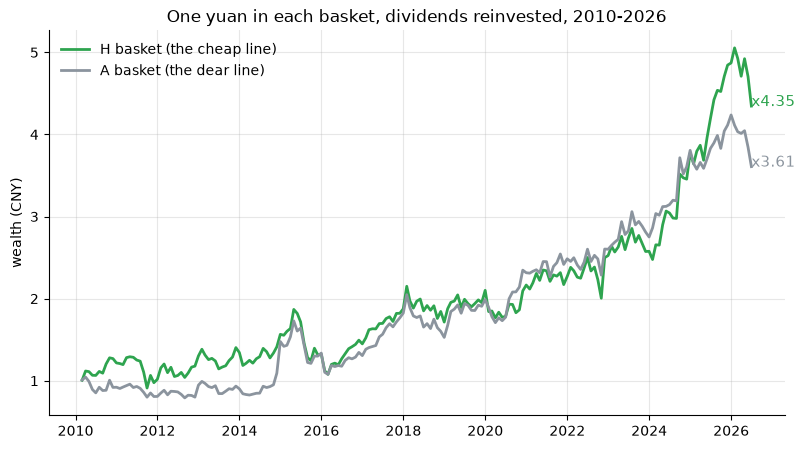

H +9.36%/yr vs A +8.13%/yr — difference +11.6 bps/mo at t = +0.42 (statistically nothing)


In [4]:
if HAVE_REAL:
    fx = data.hkd_cny(ADJ)
    h_rets, a_rets = {}, {}
    for name, a, h in data.PAIRS:
        h_rets[name] = (ADJ[h] * fx).resample('ME').last().pct_change()
        a_rets[name] = ADJ[a].resample('ME').last().pct_change()
    h_m = pd.DataFrame(h_rets).mean(axis=1).dropna()
    a_m = pd.DataFrame(a_rets).mean(axis=1).dropna()
    common = h_m.index.intersection(a_m.index)
    wh, wa = (1 + h_m[common]).cumprod(), (1 + a_m[common]).cumprod()
    fig, ax = plt.subplots()
    ax.plot(wh.index, wh.values, color=GREEN, lw=2, label='H basket (the cheap line)')
    ax.plot(wa.index, wa.values, color=GREY, lw=2, label='A basket (the dear line)')
    ax.annotate(f"x{R['h_wealth']:.2f}", xy=(wh.index[-1], wh.iloc[-1]), color=GREEN,
                fontsize=11, ha='left')
    ax.annotate(f"x{R['a_wealth']:.2f}", xy=(wa.index[-1], wa.iloc[-1]), color=GREY,
                fontsize=11, ha='left')
    ax.legend(frameon=False)
    ax.set_title('One yuan in each basket, dividends reinvested, 2010-2026')
    ax.set_ylabel('wealth (CNY)')
    plt.show()
    print(f"H {R['h_ann']:+.2f}%/yr vs A {R['a_ann']:+.2f}%/yr — difference "
          f"{R['race_bps']:+.1f} bps/mo at t = {R['race_t']:+.2f} (statistically nothing)")

The cheap line finished ahead — ×4.35 vs ×3.61 — but over sixteen years that's about **+1.2 percentage points a year with a *t*-stat of 0.4**: a coin flip. Why doesn't the discount pay? Because it **never closes** — you collect the higher dividend, but the price gap itself *widened* over the sample, handing the A side capital gains that ate most of your edge.

> 💡 The discount is only free money if it converges. A discount that random-walks is just a different price.

## 5 · The cruel joke of the tradable version

Here's the twist the quants found: *within* the family, the premium **does** mean-revert. Pairs whose premium is wide versus the pack tend to see it narrow; narrow pairs tend to widen. A paper strategy that fades this cross-section earns **~62 bps a month** with a *t*-stat of 5 — a genuinely strong signal.

And you cannot have it. The profitable half of that trade is *short the Shanghai line* of wide-premium pairs — the exact transaction the system forbids. The half you *can* do (buy A / short H in narrow pairs) survives at *t* = 2.1 gross… and dies at *t* = 1.2 after real-world costs, fading to nothing since 2018.

**The alpha lives exactly where you cannot go.** That is not a coincidence — it's *why* the alpha is still there.

## The moral

1. **The folklore is true.** Shanghai really pays ~30% more for identical cash flows, and has for a decade and a half.
2. **No convergence, no arbitrage.** The premium random-walks; every closing channel is locked by design.
3. **A locked door is not a trade.** The paper fade (*t* ≈ 5) needs the one transaction nobody may do; the executable half nets to noise.
4. **Cheap that never converges isn't cheap.** Sixteen years of a 30% discount certified... nothing.

*Numbers frozen from [docs/results.md](../docs/results.md) (as-of 2026-06-30, fingerprint `f54aaa8986a9`). Not investment advice.*